# Pharma Adherence Package Tutorial

This notebook demonstrates how to use the `pharma_adherence` package to clean prescription data, summarize patient adherence, visualize adherence patterns, and evaluate which features are most predictive of patient adherence.

The main research question for this tutorial is:

**Which features are most predictive of patient adherence?**

To answer this, we compare several logistic regression models using different feature sets. The outcome variable is `adherence_flag`, where `1` means the patient is classified as adherent and `0` means the patient is not adherent.


## 1. Import the package and supporting libraries

The package contains classes and functions for loading data, cleaning prescription records, generating visualizations, creating patient profiles, and training machine learning models.


In [13]:
import pandas as pd
import matplotlib.pyplot as plt

from src.pharma_adherence.data import PharmaDataset
from src.pharma_adherence.modeling import ModelTrainer


## 2. Load the raw prescription dataset

The `PharmaDataset` class loads the raw CSV file into a pandas DataFrame. This lets us use package methods for cleaning, visualization, saving, and patient-level summaries.


In [14]:
dataset = PharmaDataset("data/raw/prescriptions_large_raw.csv")
dataset.df.head()


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
0,P001,2024-12-30,amoxicillin,60,60,0.0,34,f,94720.0,D123,walgreens pharmacy,19.73,0,0.51
1,P001,Jan 26 2025,PANTOPRAZOLE,60,120,NaN,34,f,94720.0,D208,csv pharmacy,9,0,0.70
2,P001,Mar 02 2025,AMLODIPINE 5MG,30days,30,NaN,34,f,94720.0,D217,Walgreens,12.6,0,0.63
3,P001,2025-04-04,Metformin HCl,90 days,90,3.0,34,f,94720.0,D159,CSV #13239,$16.55,0,0.63
4,P002,12/30/2024,Albuterol 180mcg,90 days,30,NaN,40,F,90210.0,D197,Walgreens #83887,17.18,0,0.62


## 3. Clean the dataset

The `.clean()` method standardizes column names, cleans dates and numeric variables, normalizes text columns such as drug and pharmacy names, removes invalid values, drops duplicate rows, and removes records missing critical fields such as patient ID, fill date, or drug name.


In [15]:
dataset.clean()
dataset.df.head()


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
0,P001,2024-12-30,amoxicillin,60.0,60.0,0.0,34.0,female,94720.0,D123,walgreens,19.73,<NA>,0.51
1,P001,2025-01-26,pantoprazole,60.0,120.0,NaN,34.0,female,94720.0,D208,cvs,9.00,<NA>,0.70
2,P001,2025-03-02,amlodipine,30.0,30.0,NaN,34.0,female,94720.0,D217,walgreens,12.60,<NA>,0.63
3,P001,2025-04-04,metformin,90.0,90.0,3.0,34.0,female,94720.0,D159,cvs,16.55,<NA>,0.63
4,P002,2024-12-30,albuterol,90.0,30.0,NaN,40.0,female,90210.0,D197,walgreens,17.18,<NA>,0.62


Save the cleaned dataset so the processed version can be reused later.


In [16]:
dataset.save("data/processed/prescriptions_large_cleaned.csv")


## 4. Explore the cleaned data

Before modeling, it is important to inspect the cleaned dataset and understand the distribution of key adherence-related variables.


In [17]:
dataset.df.describe(include="all")


,patient_id,fill_date,drug_name,days_supply,quantity_dispensed,refill_number,patient_age,sex,zip_code,prescriber_id,pharmacy_name,copay_amount,adherence_flag,proportion_days_covered
count,1796,1796,1796,1796.00000,1796.000000,622.000000,1796.000000,1796,1329,1796,1796,1796.000000,0,1796.000000
unique,500,NaN,9,NaN,NaN,NaN,NaN,2,6,201,2,NaN,0,NaN
top,P029,NaN,pantoprazole,NaN,NaN,NaN,NaN,female,94110.0,D183,walgreens,NaN,NaN,NaN
freq,5,NaN,218,NaN,NaN,NaN,NaN,915,253,19,938,NaN,NaN,NaN
mean,NaN,2025-02-14 06:34:28.596881920,NaN,76.36971,74.097996,1.474277,52.909243,NaN,NaN,NaN,NaN,14.697389,NaN,0.661047
min,NaN,2024-12-27 00:00:00,NaN,30.00000,30.000000,0.000000,20.000000,NaN,NaN,NaN,NaN,5.000000,NaN,0.340000
25%,NaN,2025-01-05 00:00:00,NaN,60.00000,30.000000,0.000000,36.000000,NaN,NaN,NaN,NaN,9.382500,NaN,0.570000
50%,NaN,2025-02-03 00:00:00,NaN,90.00000,60.000000,1.000000,53.000000,NaN,NaN,NaN,NaN,14.655000,NaN,0.660000
75%,NaN,2025-03-06 00:00:00,NaN,120.00000,90.000000,2.000000,70.000000,NaN,NaN,NaN,NaN,20.000000,NaN,0.750000
max,NaN,2025-05-06 00:00:00,NaN,120.00000,120.000000,4.000000,85.000000,NaN,NaN,NaN,NaN,24.990000,NaN,1.000000


### Distribution of drug names

This plot shows how frequently different drugs appear in the dataset.


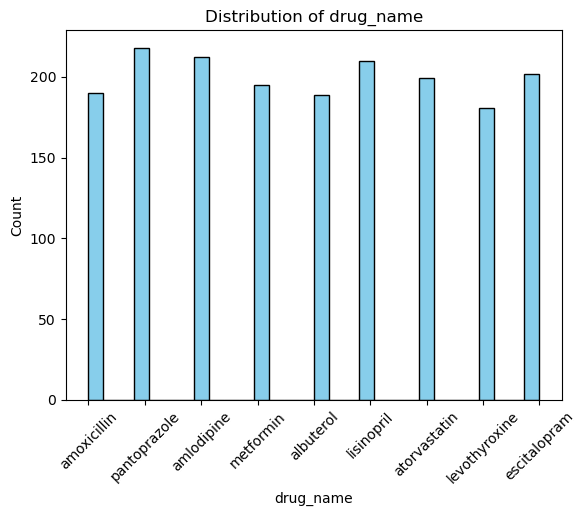

In [18]:
dataset.hist("drug_name").show()

### Average proportion of days covered by drug name

This plot compares average adherence across medication groups. Some drugs may be associated with higher or lower adherence because of side effects, dosing burden, cost, or whether the medication is used for chronic versus short-term treatment.


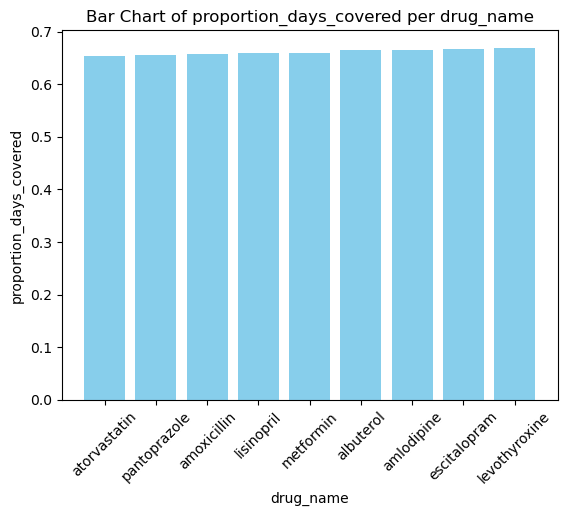

In [19]:
dataset.bar("drug_name", "proportion_days_covered").show()

### Patient age versus proportion of days covered

This scatter plot checks whether older or younger patients appear to have different adherence patterns.


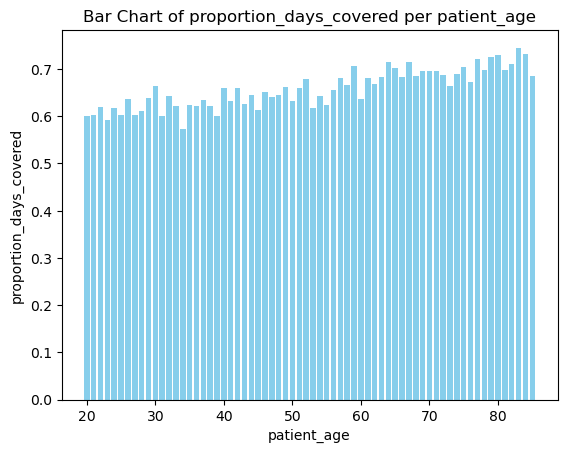

In [20]:
dataset.scatter("patient_age", "proportion_days_covered").show()


## 5. Generate a patient adherence summary

The package can summarize an individual patient's prescription history. For example, patient `P057` is summarized below.


In [21]:
patient = dataset.get_patient("P057")
patient.summary()


{'patient_id': 'P057',
 'total_fills': 1796,
 'avg_copay': np.float64(14.697388641425391),
 'avg_days_supply': np.float64(76.36971046770601),
 'pdc': np.float64(0.6610467706013362),
 'adherent': np.False_}

The patient summary includes total fills, average copay, average days supply, average proportion of days covered, and whether the patient meets the adherence threshold.


## 6. Compare feature sets for predicting adherence

To determine which features are most predictive of patient adherence, we train several logistic regression models using different feature sets. The target variable is `adherence_flag`.

The feature sets below are designed to test different clinically meaningful groups of predictors:

1. **Cost only:** `copay_amount`
2. **Demographics only:** `patient_age`, `sex`
3. **Medication burden only:** `days_supply`, `quantity_dispensed`, `refill_number`
4. **Medication identity only:** `drug_name`, `pharmacy_name`
5. **Cost + demographics:** `copay_amount`, `patient_age`, `sex`
6. **All available features:** combines cost, demographics, medication burden, medication identity, and prescriber/location information

We compare model performance using accuracy, precision, recall, and ROC-AUC. ROC-AUC is especially useful because it measures how well the model separates adherent from non-adherent patients across thresholds.


In [22]:
import time
import pandas as pd

try:
    from tqdm.notebook import tqdm
except ImportError:
    tqdm = None


feature_sets = {
    "cost_only": ["copay_amount"],

    "demographics_only": ["patient_age", "sex"],

    "medication_burden_only": [
        "days_supply",
        "quantity_dispensed",
        "refill_number"
    ],

    "medication_identity_only": [
        "drug_name",
        "pharmacy_name"
    ],

    "cost_plus_demographics": [
        "copay_amount",
        "patient_age",
        "sex"
    ],

    "cost_plus_medication_burden": [
        "copay_amount",
        "days_supply",
        "quantity_dispensed",
        "refill_number"
    ],

    "core_features": [
        "copay_amount",
        "patient_age",
        "sex",
        "days_supply",
        "quantity_dispensed",
        "refill_number",
        "drug_name",
        "pharmacy_name"
    ],
}

results = []

iterator = feature_sets.items()
if tqdm is not None:
    iterator = tqdm(iterator, total=len(feature_sets), desc="Training feature-set models")

for name, features in iterator:
    start_time = time.time()
    print(f"\nStarting model: {name}")
    print(f"Features: {features}")

    try:
        # Keep only the selected features and target.
        model_df = dataset.df[features + ["adherence_flag"]].copy()

        # Remove rows missing the target.
        model_df = model_df.dropna(subset=["adherence_flag"])

        # Make sure target is numeric binary.
        model_df["adherence_flag"] = model_df["adherence_flag"].astype(int)

        # Train logistic regression using your package's ModelTrainer.
        trainer = ModelTrainer(model_df, "adherence_flag", features)
        model, metrics = trainer.train_logistic()

        elapsed = round(time.time() - start_time, 2)

        print(f"Finished model: {name} in {elapsed} seconds")
        print(metrics)

        results.append({
            "feature_set": name,
            "features": ", ".join(features),
            "runtime_seconds": elapsed,
            **metrics,
            "error": None
        })

    except Exception as e:
        elapsed = round(time.time() - start_time, 2)

        print(f"Model failed: {name}")
        print(f"Error: {e}")

        results.append({
            "feature_set": name,
            "features": ", ".join(features),
            "runtime_seconds": elapsed,
            "accuracy": None,
            "precision": None,
            "recall": None,
            "roc_auc": None,
            "error": str(e)
        })

results_df = pd.DataFrame(results).sort_values(
    "roc_auc",
    ascending=False,
    na_position="last"
)

results_df


Starting model: cost_only
Features: ['copay_amount']
Model failed: cost_only
Error: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

Starting model: demographics_only
Features: ['patient_age', 'sex']
Model failed: demographics_only
Error: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

Starting model: medication_burden_only
Features: ['days_supply', 'quantity_dispensed', 'refill_number']
Model failed: medication_burden_only
Error: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforementioned parameters.

Starting model: medication_identity_only
Features: ['drug_name', 'pharmacy_name']
Model failed: medication_identity_only
Error: With n_samples=0, test_size=0.2 and train_size=None, the resulting train set will be empty. Adjust any of the aforement

,feature_set,features,runtime_seconds,accuracy,precision,recall,roc_auc,error
0,cost_only,copay_amount,0.01,None,None,None,None,"With n_samples=0, test_size=0.2 and train_size..."
1,demographics_only,"patient_age, sex",0.00,None,None,None,None,"With n_samples=0, test_size=0.2 and train_size..."
2,medication_burden_only,"days_supply, quantity_dispensed, refill_number",0.00,None,None,None,None,"With n_samples=0, test_size=0.2 and train_size..."
3,medication_identity_only,"drug_name, pharmacy_name",0.00,None,None,None,None,"With n_samples=0, test_size=0.2 and train_size..."
4,cost_plus_demographics,"copay_amount, patient_age, sex",0.00,None,None,None,None,"With n_samples=0, test_size=0.2 and train_size..."
5,cost_plus_medication_burden,"copay_amount, days_supply, quantity_dispensed,...",0.00,None,None,None,None,"With n_samples=0, test_size=0.2 and train_size..."
6,core_features,"copay_amount, patient_age, sex, days_supply, q...",0.00,None,None,None,None,"With n_samples=0, test_size=0.2 and train_size..."


In [23]:
dataset.df["adherence_flag"].value_counts(dropna=False)
dataset.df[["adherence_flag"]].head(20)

,adherence_flag
0,<NA>
1,<NA>
2,<NA>
3,<NA>
4,<NA>
5,<NA>
6,<NA>
7,<NA>
8,<NA>
9,<NA>


## 7. Visualize model performance

The bar chart below compares ROC-AUC across feature sets. The best feature set is the one with the highest ROC-AUC.


TypeError: unsupported operand type(s) for +: 'int' and 'NoneType'

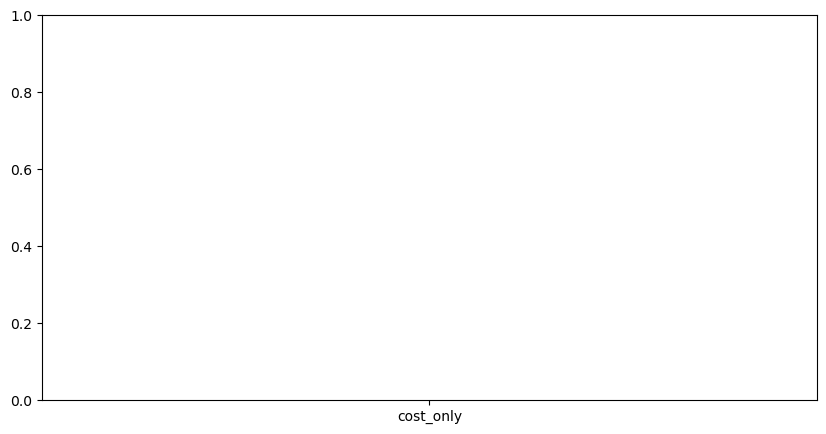

In [24]:
plt.figure(figsize=(10, 5))
plt.bar(results_df["feature_set"], results_df["roc_auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("ROC-AUC")
plt.title("Comparison of Feature Sets for Predicting Adherence")
plt.tight_layout()
plt.show()


## 8. Identify the best feature set

The code below selects the feature set with the highest ROC-AUC.


In [ ]:
best_model = results_df.iloc[0]

print("Best feature set:", best_model["feature_set"])
print("Features:", best_model["features"])
print("ROC-AUC:", best_model["roc_auc"])
print("Accuracy:", best_model["accuracy"])
print("Precision:", best_model["precision"])
print("Recall:", best_model["recall"])


## 9. Interpretation: Which features are most predictive of patient adherence?

The best feature set should be interpreted based on the table above after running the notebook. In general, if the **all_features** model performs best, that suggests adherence is multifactorial and is influenced by a combination of cost, patient demographics, medication characteristics, pharmacy access, and prescriber-level patterns.

From a pharmacy and medication adherence perspective, this makes sense. **Copay amount** can affect adherence because higher out-of-pocket cost may make it harder for patients to refill medications consistently. **Days supply**, **quantity dispensed**, and **refill number** are directly related to refill behavior and medication availability, so they are expected to be strong predictors of adherence. **Drug name** may also matter because medications differ in side effects, dosing schedules, perceived benefit, and whether they treat chronic versus short-term conditions. **Pharmacy name** and **zip code** may reflect access-related factors such as convenience, insurance networks, neighborhood resources, or refill coordination. **Age and sex** may contribute to adherence patterns, but they are usually less directly connected to refill behavior than medication supply, cost, and pharmacy-related variables.

If a smaller feature set performs almost as well as all features, the simpler model may be preferred because it is easier to explain. For example, if the medication burden model performs similarly to the all-features model, then refill-related variables such as days supply, quantity dispensed, and refill number may be the most practically important predictors in this dataset.

Overall, the results should be judged by both model performance and domain plausibility. A strong adherence model should not only have good ROC-AUC, but also rely on predictors that make clinical and pharmacy sense.


## 10. Conclusion

This tutorial demonstrated the main functionality of the `pharma_adherence` package. The package was used to load and clean prescription data, save a processed dataset, visualize adherence-related variables, generate a patient adherence profile, and compare multiple feature sets for predicting adherence. The feature comparison shows how machine learning can be used not only for prediction, but also for understanding which types of variables may be most informative for medication adherence.
